# Testando Algoritmo de RandomForest com GKFold para predição de resistência à Compressão

In [1]:
%%capture
!pip install optuna

In [2]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm.notebook import tqdm
import os, optuna
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'
filename = 'df_resistencia_sem_feature_engineering.pkl'
file_path = os.path.join(dirpath, filename)
os.listdir(dirpath)
df = pd.read_pickle(file_path)
df['target'] = df['Resistencia_Compressao_MPa'].copy()
df.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 551 entries, 15 to 598
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Autores/ano                  551 non-null    object 
 1   Massa_Esp_Cimento_g_cm3      551 non-null    float64
 2   Finura_Cimento_Blaine_m2_kg  551 non-null    float64
 3   Massa_Esp_Filer_g_cm3        551 non-null    float64
 4   Massa_Esp_Areia_g_cm3        551 non-null    float64
 5   Massa_Esp_Brita_g_cm3        551 non-null    float64
 6   Cimento_kg_m3                551 non-null    float64
 7   Filer_Calcario_kg_m3         551 non-null    float64
 8   Agua_kg_m3                   551 non-null    float64
 9   Agregado_Miudo_Total_kg_m3   551 non-null    float64
 10  Agregado_Graudo_Total_kg_m3  551 non-null    float64
 11  Superplastificante_kg_m3     551 non-null    float64
 12  Relacao_Agua_Cimento         551 non-null    float64
 13  idade                   

In [5]:
n_groups = df['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 17


# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 150

pbar = tqdm(total=n_trials, desc="Otimizando")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]   
)

pbar.close()

print("\n" + "="*50)
print("🏆 OTIMIZAÇÃO CONCLUÍDA")
print("="*50)
print(f"Melhor RMSE alcançado (Cross-Validation): {study.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study.best_params.items():
    print(f"  '{key}': {value},")

In [6]:
best_params = {
    'n_estimators': 520,
    'max_depth': 5,
    'max_samples': 0.6967763339125419,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': "sqrt"
}

In [8]:
X = df.drop(columns=['target', 'Autores/ano'])
y = df['target']
groups = df['Autores/ano']

In [9]:
all_train_curves = []
all_oob_curves = []
all_val_curves = []
all_true = []
all_preds = []
all_groups = []

for fold, (train_idx, val_idx) in tqdm(
    enumerate(gkf.split(X, y, groups)),
    total=gkf.get_n_splits(),
    desc="Folds",
    unit="fold"
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    params = best_params.copy()

    params.update({
        'random_state': 42,
        'n_jobs': -1,
        'bootstrap': True,
        'oob_score': True,
        'warm_start': True
    })

    rf = RandomForestRegressor(**params)

    fold_train = []
    fold_oob = []
    fold_val = []

    for n in range(10, params['n_estimators'] + 1, 10):

        rf.set_params(n_estimators=n)
        rf.fit(X_train, y_train)

        # treino
        fold_train.append(
            root_mean_squared_error(
                y_train,
                rf.predict(X_train)
            )
        )

        # OOB
        fold_oob.append(
            root_mean_squared_error(
                y_train,
                rf.oob_prediction_
            )
        )

        # validação
        fold_val.append(
            root_mean_squared_error(
                y_val,
                rf.predict(X_val)
            )
        )

    all_train_curves.append(fold_train)
    all_oob_curves.append(fold_oob)
    all_val_curves.append(fold_val)

    preds_val_final = rf.predict(X_val)

    all_true.extend(y_val.tolist())
    all_preds.extend(preds_val_final.tolist())
    all_groups.extend(groups.iloc[val_idx].tolist())

Folds:   0%|          | 0/17 [00:00<?, ?fold/s]

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

In [10]:
all_train_curves = np.array(all_train_curves)
all_oob_curves = np.array(all_oob_curves)
all_val_curves = np.array(all_val_curves)

train_mean = all_train_curves.mean(axis=0)
train_std = all_train_curves.std(axis=0)

oob_mean = all_oob_curves.mean(axis=0)
oob_std = all_oob_curves.std(axis=0)

val_mean = all_val_curves.mean(axis=0)
val_std = all_val_curves.std(axis=0)

n_trees = np.arange(10, best_params['n_estimators'] + 1,10)

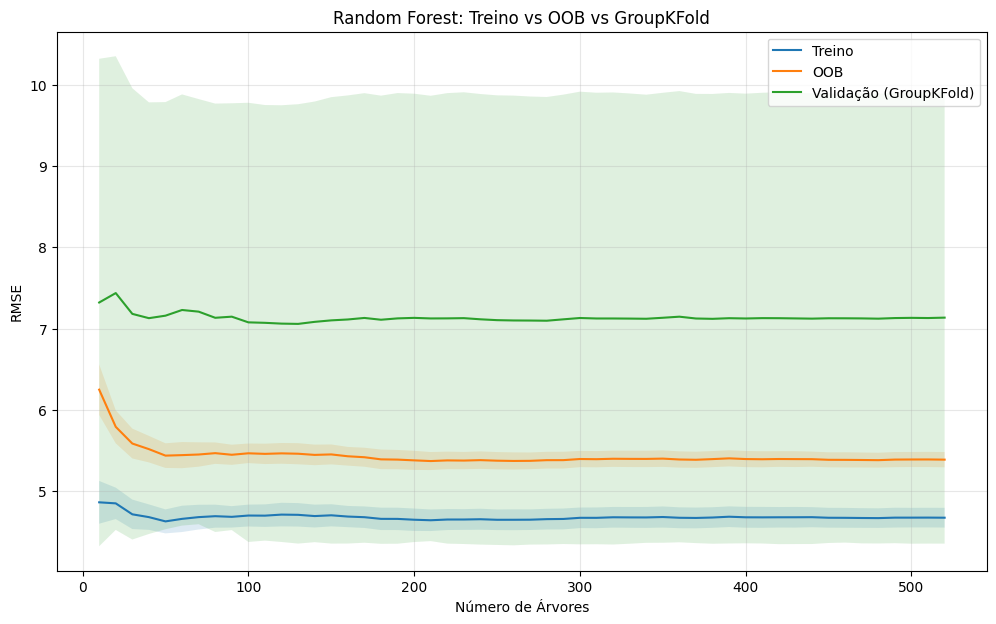

In [11]:
plt.figure(figsize=(12, 7))

plt.plot(
    n_trees,
    train_mean,
    label='Treino'
)

plt.plot(
    n_trees,
    oob_mean,
    label='OOB'
)

plt.plot(
    n_trees,
    val_mean,
    label='Validação (GroupKFold)'
)

plt.fill_between(
    n_trees,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    n_trees,
    oob_mean - oob_std,
    oob_mean + oob_std,
    alpha=0.15
)

plt.fill_between(
    n_trees,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15
)

plt.xlabel('Número de Árvores')
plt.ylabel('RMSE')
plt.title('Random Forest: Treino vs OOB vs GroupKFold')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [12]:
all_train_curves = np.array(all_train_curves)
all_oob_curves = np.array(all_oob_curves)
all_val_curves = np.array(all_val_curves)

train_final = np.mean(all_train_curves[:, -1])
val_final = np.mean(all_val_curves[:, -1])

train_final_std = np.std(all_train_curves[:, -1])
val_final_std = np.std(all_val_curves[:, -1])

overfitting_gap = val_final - train_final

print("\n" + "="*60)
print("📊 RESUMO DAS CURVAS DE APRENDIZADO")
print("="*60)
print("Métrica: último ponto disponível de cada fold")
print(f"✅ RMSE Treino (final por fold):      {train_final:.6f}")
print(f"⚠️  RMSE Validação (final por fold):   {val_final:.6f}")
print(f"📈 Gap (Val - Train):                 {overfitting_gap:.6f}")
print("="*60)


📊 RESUMO DAS CURVAS DE APRENDIZADO
Métrica: último ponto disponível de cada fold
✅ RMSE Treino (final por fold):      4.675224
⚠️  RMSE Validação (final por fold):   7.135219
📈 Gap (Val - Train):                 2.459995


In [13]:
debug_df = pd.DataFrame({
    'y_true': all_true,
    'y_pred': all_preds,
    'group': all_groups
})

debug_df['residual'] = (
    debug_df['y_true'] - debug_df['y_pred']
)

debug_df['abs_error'] = (
    debug_df['residual'].abs()
)

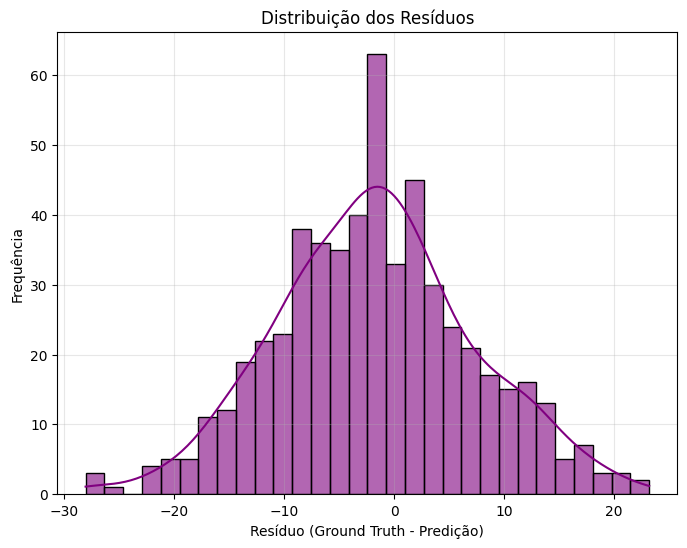

In [14]:
plt.figure(figsize=(8, 6))

sns.histplot(
    debug_df['residual'],
    bins=30,
    kde=True,
    color='purple',
    alpha=0.6
)

plt.title("Distribuição dos Resíduos")
plt.xlabel("Resíduo (Ground Truth - Predição)")
plt.ylabel("Frequência")

plt.grid(True, alpha=0.3)

plt.show()

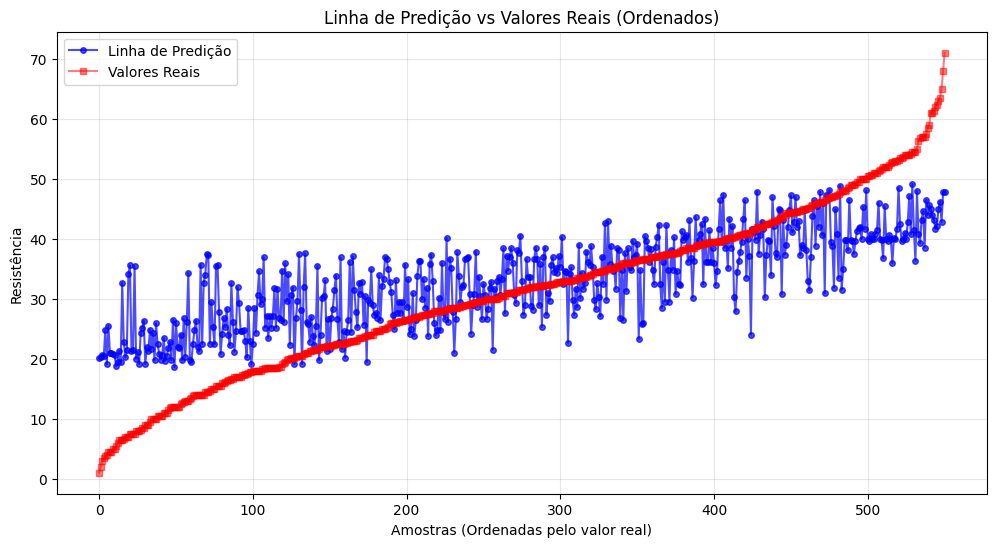

In [15]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = debug_df.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["y_pred"], color='blue', label="Linha de Predição",
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["y_true"], color='red', label="Valores Reais",
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados)")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Resistência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 9.0951
mean_absolute_error: 7.2030
mean_absolute_percentage_error: 0.4564
R² Score: 55.6750


In [18]:
model = RandomForestRegressor(**best_params)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, max_features='sqrt',
                      max_samples=0.6967763339125419, n_estimators=520)

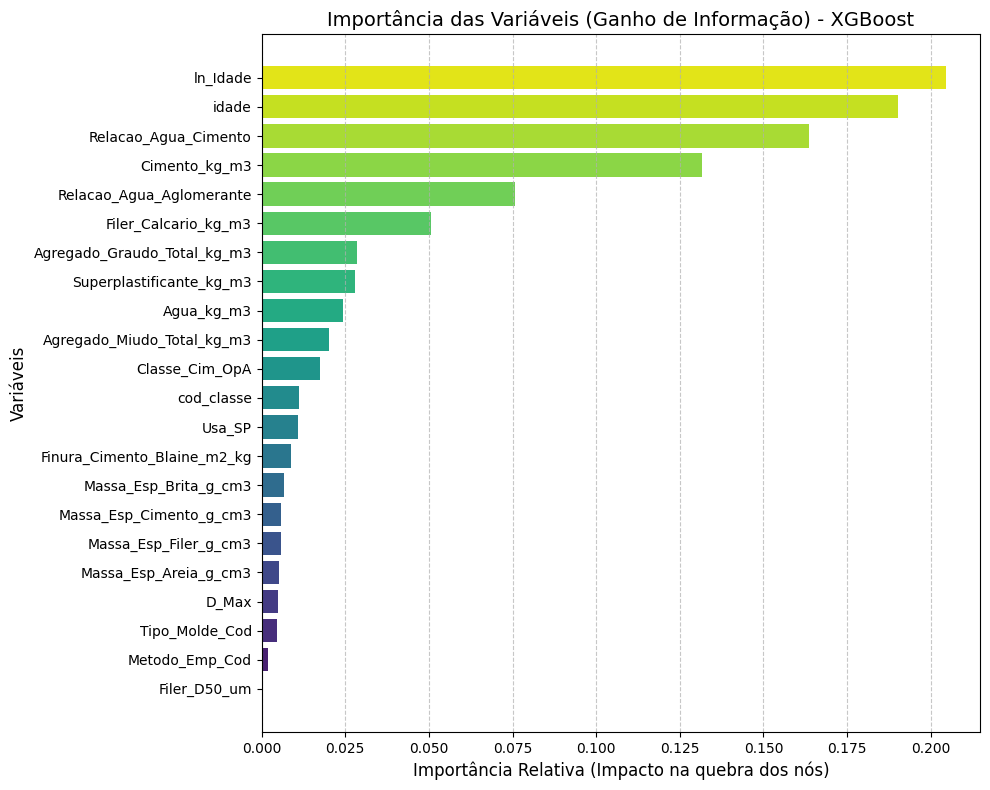

In [19]:
# 1. Extraindo as importâncias direto do modelo XGBoost treinado
# (Assumindo que o seu modelo se chame 'model_xgb')
importancias_xgb = model.feature_importances_

# 2. Criando o DataFrame para organizar os dados
df_importancia_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importancia': importancias_xgb
})

# Ordenando da maior para a menor importância
df_importancia_xgb = df_importancia_xgb.sort_values(by='Importancia', ascending=True)

# 3. Plotando o Gráfico
plt.figure(figsize=(10, 8))

# Criando uma paleta de cores (usando o 'viridis' para diferenciar do gráfico anterior)
cores = sns.color_palette('viridis', n_colors=len(df_importancia_xgb))

# Plotando as barras horizontais
plt.barh(
    y=df_importancia_xgb['Feature'],
    width=df_importancia_xgb['Importancia'],
    color=cores,
    edgecolor='none'
)

plt.title('Importância das Variáveis (Ganho de Informação) - XGBoost', fontsize=14)
plt.xlabel('Importância Relativa (Impacto na quebra dos nós)', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()